In [ ]:
! pip install numpy
! pip install matplotlib
! pip install scipy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

# Basic

## Optimization

In [3]:
from scipy.optimize import minimize

Minimize $f(x) = (x-3)^2$

In [4]:
def f(x):
    return (x-3)**2

res = minimize(f, x0=2) # x0 = initial guess value
res.x # at x = 2.99999999, it has the least value
# res

array([2.99999999])

Minimize $f(x, y) = (x-1)^2 + (y-2.5)^2$ subject to


$$x - 2y + 2 \geq 0$$
$$-x - 2y + 6 \geq 0$$
$$-x + 2y + 2 \geq 0$$
$$x \geq 0$$
$$y \geq 0$$

<p align="center">
  <img src="./opt_reg.PNG" alt="drawing" width="300" align="center"/>
</p>

* 2D function takes in vector $x$
* Constraints must be specified as $g_i(x) \geq 0$
* Bounds specified as rectangular

In [5]:
f = lambda x: (x[0] - 1)**2 + (x[1] - 2.5)**2
# f([1,2]) # x[0] is 1st arg: x, x[1] is 2nd arg: y

# constraints
cons = ({'type': 'ineq', 'fun': lambda x:  x[0] - 2 * x[1] + 2},
        {'type': 'ineq', 'fun': lambda x: -x[0] - 2 * x[1] + 6},
        {'type': 'ineq', 'fun': lambda x: -x[0] + 2 * x[1] + 2})

# bounds
bnds = ((0, None), (0, None)) # for x[0], x[1] # None means no upper limit

# 4. Set Initial Guess and Run Optimization
x0 = (2, 0) # np.array([0.0, 0.0]) # Starting point (must be within or near the feasible region)
res = minimize(f, x0=x0, bounds=bnds, constraints=cons)

res.x # array([1.4, 1.7])

array([1.4, 1.7])

In [6]:
# minimize?
#to see docs

## Interpolation

Suppose you have the following data (I generate it here, but perhaps you collect `x` and `y` by means of some experiment)

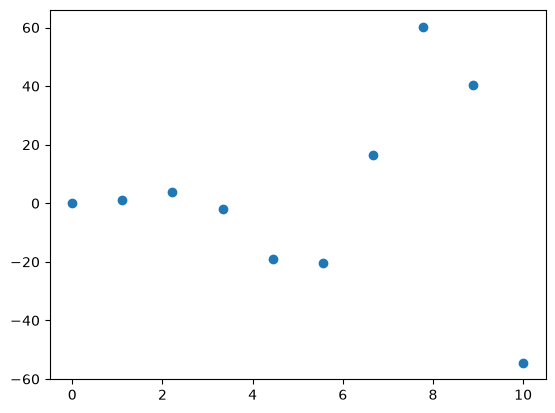

In [7]:
x = np.linspace(0, 10, 10)
y = x**2 * np.sin(x)
plt.scatter(x,y)

You want to know the values in between.


In [13]:
from scipy.interpolate import interp1d


In [9]:
f = interp1d(x, y, kind='cubic') # interp1d(x, y, kind='linear')
x_dense = np.linspace(0, 10, 100)
y_dense = f(x_dense)

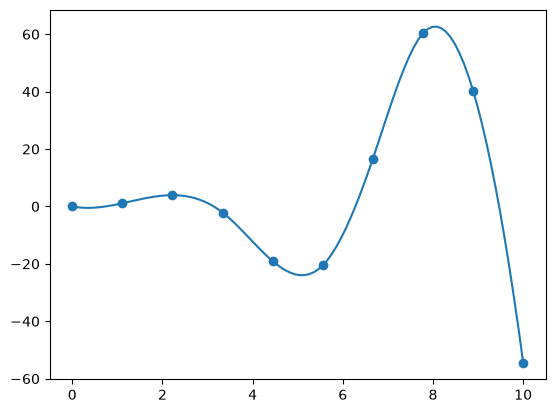

In [10]:
plt.plot(x_dense, y_dense)
plt.scatter(x, y)

## Curve Fitting
Trivial Example

In [11]:
x_data = np.linspace(0, 10, 10) # generates a sequence of evenly spaced numbers over a specified interval.
y_data = 3*x_data**2 + 2
print(x_data)
print(y_data)

[ 0.          1.11111111  2.22222222  3.33333333  4.44444444  5.55555556
  6.66666667  7.77777778  8.88888889 10.        ]
[  2.           5.7037037   16.81481481  35.33333333  61.25925926
  94.59259259 135.33333333 183.48148148 239.03703704 302.        ]


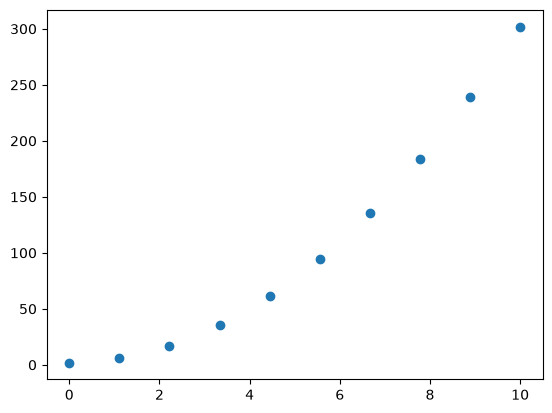

In [12]:
plt.scatter(x_data, y_data)
